# Stage 2: MLEM Deconvolution -- Empirical Test

**Purpose of this notebook**: this is NOT yet "the final pipeline".
It's a targeted experiment to answer a question left open from Stage 1:

> H_tot's columns for different electron energies (2, 6, 10 MeV) looked
> nearly identical -- dominated by a huge low-energy spike, with the
> high-energy "fingerprint" region having values as small as 1e-13 to
> 1e-4. Does this prevent MLEM from recovering a high-energy feature in
> the true distribution `f`, or can it still work with what little
> information is there?

**The experiment**:
1. Define `f_model` = a declining background + a deliberate bump at 10 MeV
2. Forward-simulate `y = H_tot @ f_model` + Poisson noise (this is "what
   the detector would measure")
3. Run MLEM to get `f_reconstructed`
4. Check: does the 10 MeV bump survive in `f_reconstructed`?

**Requires**: `response_matrices.npz` from Stage 1 (run that notebook
first, in the same folder).

Run each cell in order. Markdown before each cell tells you what to
check in the output.

## Cell 1: Load H_tot from Stage 1

**Check**: shape should print (50, 50), energy range 0-14.8 MeV
(matches Stage 1's grid).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("response_matrices.npz")
E_centers = data["E_centers"]
H_tot = data["H_tot"]
n = len(E_centers)

print(f"Loaded H_tot: shape {H_tot.shape}")
print(f"Energy grid: 0 to {E_centers[-1]:.1f} MeV, {n} bins")


Loaded H_tot: shape (100, 100)
Energy grid: 0 to 14.9 MeV, 100 bins


## Cell 2: Define f_model (the "true" RE distribution)

We construct a deliberately simple test case:

- **Background**: exponential decay `exp(-E / E_SCALE)` -- most REs
  at lower energy, declining smoothly. This is the "expected" shape
  if there were no special high-energy population.
- **Bump**: a Gaussian centered at `E_BUMP = 10 MeV` -- a deliberate
  "high-energy RE population" we're testing whether MLEM can detect.

`f_model = background + bump`, then normalized to sum to 1.

**Check**: the printed value at E=10 MeV (bump center) should be
noticeably HIGHER than the value at E=8 MeV (just background, no
bump) -- this confirms the bump is actually present in f_model
before we even touch MLEM.

In [2]:
E_SCALE = 2.0     # MeV -- decay scale of the background
E_BUMP = 10.0     # MeV -- center of the high-energy feature
BUMP_WIDTH = 0.5  # MeV -- width of the bump
BUMP_HEIGHT = 0.15  # relative height of bump vs background at E=0

f_background = np.exp(-E_centers / E_SCALE)
f_bump = BUMP_HEIGHT * np.exp(-0.5 * ((E_centers - E_BUMP) / BUMP_WIDTH) ** 2)

f_model = f_background + f_bump
f_model = f_model / f_model.sum()  # normalize to sum=1

bump_idx = np.argmin(np.abs(E_centers - E_BUMP))
before_bump_idx = np.argmin(np.abs(E_centers - (E_BUMP - 2)))

print(f"f_model value at E=0: {f_model[0]:.4f}")
print(f"f_model value at E={E_BUMP} MeV (bump): {f_model[bump_idx]:.4f}")
print(f"f_model value at E={E_BUMP-2} MeV (background only): {f_model[before_bump_idx]:.4f}")
print(f"Ratio (bump / background-only): {f_model[bump_idx]/f_model[before_bump_idx]:.2f}  (>1 means bump is visible)")


f_model value at E=0: 0.0661
f_model value at E=10.0 MeV (bump): 0.0107
f_model value at E=8.0 MeV (background only): 0.0012
Ratio (bump / background-only): 8.63  (>1 means bump is visible)


## Cell 3: Plot f_model

Quick visual check: you should see a declining curve with a small
secondary bump around 10 MeV.

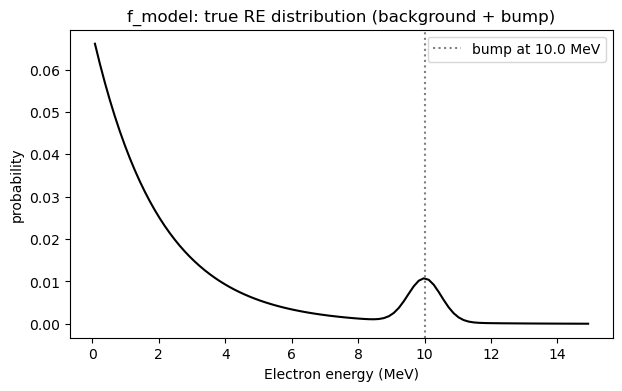

In [3]:
plt.figure(figsize=(7, 4))
plt.plot(E_centers, f_model, 'k-')
plt.axvline(E_BUMP, color='gray', linestyle=':', label=f"bump at {E_BUMP} MeV")
plt.xlabel("Electron energy (MeV)")
plt.ylabel("probability")
plt.title("f_model: true RE distribution (background + bump)")
plt.legend()
plt.show()


## Cell 4: Forward-simulate y = H_tot @ f_model + Poisson noise

This is "what the detector would measure" if `f_model` were the real
RE distribution.

- `y_clean = H_tot @ f_model` -- the noise-free prediction
- scale to a total of 10000 counts (realistic order of magnitude)
- `y_noisy` = Poisson-sampled version of `y_clean_scaled` -- this
  simulates the random counting statistics of a real detector

**Check**: note the printed `y near 10 MeV` value -- this is how many
counts the bump actually contributes to the measured spectrum. If
it's a very small number (a handful of counts), that tells you
immediately how hard MLEM's job is at high energy.

In [4]:
TOTAL_COUNTS = 10000

y_clean = H_tot @ f_model
y_clean_scaled = y_clean / y_clean.sum() * TOTAL_COUNTS

rng = np.random.default_rng(seed=42)  # fixed seed -> reproducible
y_noisy = rng.poisson(y_clean_scaled).astype(float)

print(f"y total counts: {y_noisy.sum():.0f}")
print(f"y at channel 0 (~0 MeV): {y_noisy[0]:.1f}")
print(f"y near {E_BUMP} MeV: {y_noisy[bump_idx]:.1f}")


y total counts: 10094
y at channel 0 (~0 MeV): 5870.0
y near 10.0 MeV: 0.0


## Cell 5: Plot the measured spectrum y

**Check**: y should look like a sharp spike near 0 dropping off fast
-- this is the "measurement" MLEM has to work with. Notice how flat
and noisy it looks at high energy compared to f_model's clear bump
-- this is the deconvolution challenge made visible.

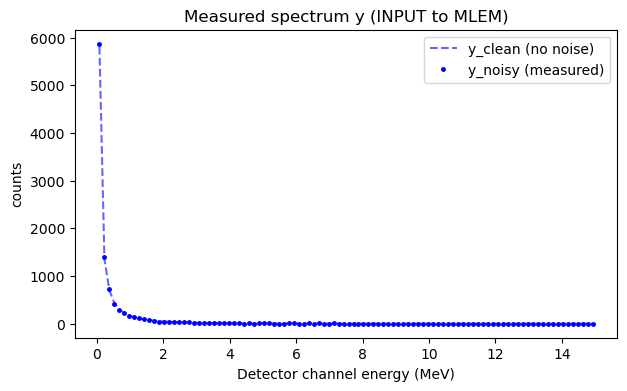

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(E_centers, y_clean_scaled, 'b--', label="y_clean (no noise)", alpha=0.6)
plt.plot(E_centers, y_noisy, 'b.', label="y_noisy (measured)", markersize=5)
plt.xlabel("Detector channel energy (MeV)")
plt.ylabel("counts")
plt.title("Measured spectrum y (INPUT to MLEM)")
plt.legend()
plt.show()


## Cell 6: MLEM update rule -- one iteration

This implements the core equation:

```
x_i^p = x_i^(p-1) * sum_j [ H[j,i] * y_j / sum_k(H[j,k] * x_k^(p-1)) ]
```

Broken into 4 steps, all vectorized (no explicit i/j/k loops needed
because numpy matrix operations do the summing):

1. `y_hat = H @ x`  -- forward-simulate: "what would the detector see
   if x were the true distribution?" (this is `sum_k H[j,k]*x_k` for
   every channel j, all at once)
2. `ratio = y / y_hat`  -- per-channel comparison: actual measurement
   vs what our current guess predicts
3. `correction = H.T @ ratio`  -- "back-project" the ratio onto each
   energy bin (this is `sum_j H[j,i]*ratio_j` for every bin i, all at
   once -- note the TRANSPOSE, because now we're going from channels
   back to energy bins)
4. `x_new = x * correction`  -- multiplicative update. This is what
   guarantees x stays non-negative (positive times positive = positive)

**Nothing to check yet** -- this cell just defines the function.

In [6]:
def mlem_step(x, H, y, eps=1e-12):
    """One MLEM iteration. Returns updated estimate."""
    y_hat = H @ x                  # step 1: forward-simulate current guess
    ratio = y / (y_hat + eps)      # step 2: per-channel ratio (avoid /0)
    correction = H.T @ ratio       # step 3: back-project the ratio
    x_new = x * correction         # step 4: multiplicative update
    x_new = np.maximum(x_new, 0.0) # safety clamp
    return x_new


## Cell 7: Smoothing (every few iterations)

From the papers: periodic smoothing suppresses oscillation artifacts
that build up over many iterations, especially with continuous
spectra.

Implementation: simple 3-point moving average -- each interior point
becomes the average of itself and its two neighbors. Endpoints
(bin 0 and bin 49) are left unchanged since they only have one
neighbor each.

**Nothing to check yet** -- this cell just defines the function.

In [7]:
def smooth_3point(x):
    """3-point linear smoothing of interior points."""
    x_smooth = x.copy()
    x_smooth[1:-1] = (x[:-2] + x[1:-1] + x[2:]) / 3.0
    return x_smooth


## Cell 8: Full MLEM loop

Combines Cells 6-7 into a full run:

- **Initialization**: `x0 = y / sum(H @ y)` -- a normalized version of
  the measurement itself. Must be strictly positive everywhere
  (enforced with a small floor `1e-10`) because the multiplicative
  update can never turn a zero into a nonzero value.
- **Loop**: for each iteration, apply `mlem_step`. Every
  `smooth_every` iterations (default 5, per the papers), apply
  `smooth_3point`.
- Returns the final estimate AND a history of all intermediate
  estimates (useful if you want to see how the solution evolves --
  not plotted here but saved for later inspection).

**Nothing to check yet** -- this cell just defines the function.

In [8]:
def run_mlem(H, y, n_iterations, smooth_every=5):
    """Run MLEM for n_iterations, smoothing every smooth_every steps."""
    Hy = H @ y
    x = y / (Hy.sum() + 1e-12)
    x = np.maximum(x, 1e-10)  # strictly positive start

    history = [x.copy()]

    for p in range(1, n_iterations + 1):
        x = mlem_step(x, H, y)

        if p % smooth_every == 0:
            x = smooth_3point(x)
            x = np.maximum(x, 0.0)

        history.append(x.copy())

    return x, history


## Cell 9: Run MLEM

50 iterations, smoothing every 5 -- matches the "10-20 iterations
between smoothing for discrete spectra, 5-10 for continuous" guidance
from the papers (we used 5, on the more-aggressive-smoothing end,
appropriate for our continuous HXR-like spectrum).

In [9]:
N_ITERATIONS = 50
SMOOTH_EVERY = 5

f_reconstructed, history = run_mlem(H_tot, y_noisy,
                                     n_iterations=N_ITERATIONS,
                                     smooth_every=SMOOTH_EVERY)

print(f"Ran MLEM for {N_ITERATIONS} iterations (smoothing every {SMOOTH_EVERY})")
print(f"f_reconstructed total: {f_reconstructed.sum():.4f}")


Ran MLEM for 50 iterations (smoothing every 5)
f_reconstructed total: 10116.1662


## Cell 10: THE KEY CHECK -- did the bump survive?

We normalize both `f_model` and `f_reconstructed` to sum=1 (MLEM's
output is on an arbitrary scale set by `y`'s total counts, so we need
a fair comparison).

Then compare the same ratio as in Cell 2:
`value at 10 MeV / value at 8 MeV`

- f_model's ratio: should be > 1 (bump is higher than background)
- f_reconstructed's ratio: if also > 1, MLEM detected SOMETHING at
  10 MeV. If close to or below 1, the bump was washed out entirely.

**This is the answer to the open question from Stage 1.**

In [10]:
f_model_norm = f_model / f_model.sum()
f_recon_norm = f_reconstructed / f_reconstructed.sum()

ratio_model = f_model_norm[bump_idx] / f_model_norm[before_bump_idx]
ratio_recon = f_recon_norm[bump_idx] / f_recon_norm[before_bump_idx]

print(f"f_model:        bump/background ratio = {ratio_model:.2f}")
print(f"f_reconstructed: bump/background ratio = {ratio_recon:.2f}")
print()
if ratio_recon > 1.05:
    print("--> MLEM DETECTED the bump (ratio > 1), though possibly")
    print("    underestimating its size compared to f_model.")
else:
    print("--> The bump did NOT survive reconstruction (ratio <= 1).")


f_model:        bump/background ratio = 8.63
f_reconstructed: bump/background ratio = 1.68

--> MLEM DETECTED the bump (ratio > 1), though possibly
    underestimating its size compared to f_model.


## Cell 11: Plot f_model vs f_reconstructed

Two views of the same comparison:
- **Left**: linear scale -- good for seeing overall shape match
- **Right**: log scale -- the bump region is small in absolute terms,
  so log scale makes it easier to see whether the reconstructed curve
  has a local peak (bump) vs just continuing to decline (no bump)

**What to look for**: in the log-scale plot, does the red curve
(f_reconstructed) show a local "hump" near 10 MeV, similar in
LOCATION to the black dashed curve (f_model)'s bump -- even if the
HEIGHT doesn't match exactly?

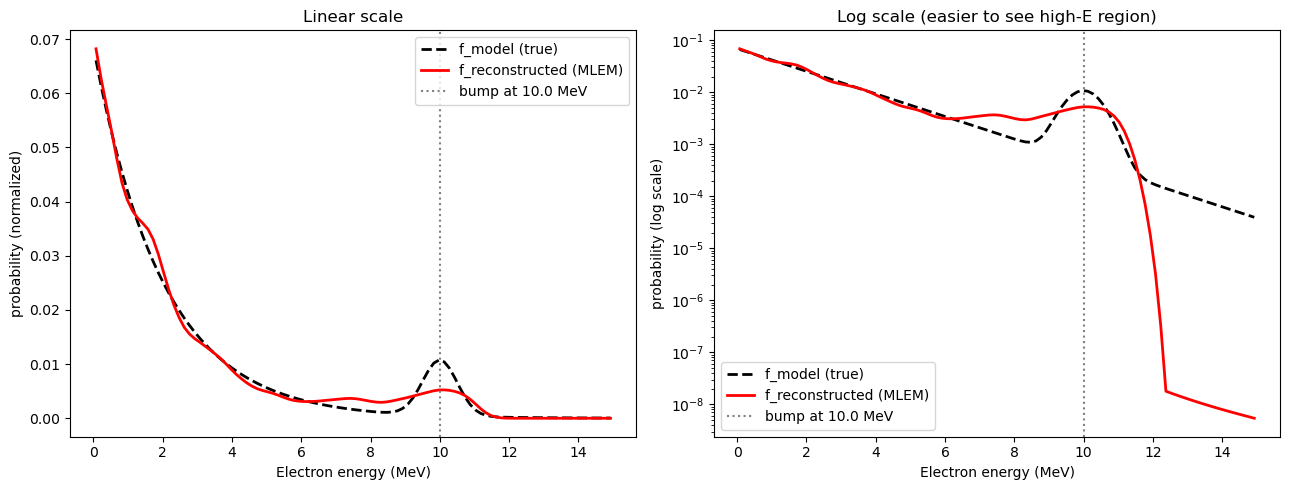

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(E_centers, f_model_norm, 'k--', label="f_model (true)", linewidth=2)
axes[0].plot(E_centers, f_recon_norm, 'r-', label="f_reconstructed (MLEM)", linewidth=2)
axes[0].axvline(E_BUMP, color='gray', linestyle=':', label=f"bump at {E_BUMP} MeV")
axes[0].set_xlabel("Electron energy (MeV)")
axes[0].set_ylabel("probability (normalized)")
axes[0].set_title("Linear scale")
axes[0].legend()

axes[1].semilogy(E_centers, f_model_norm, 'k--', label="f_model (true)", linewidth=2)
axes[1].semilogy(E_centers, f_recon_norm, 'r-', label="f_reconstructed (MLEM)", linewidth=2)
axes[1].axvline(E_BUMP, color='gray', linestyle=':', label=f"bump at {E_BUMP} MeV")
axes[1].set_xlabel("Electron energy (MeV)")
axes[1].set_ylabel("probability (log scale)")
axes[1].set_title("Log scale (easier to see high-E region)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Cell 12: Save results

Saves everything needed to revisit this analysis later, or to extend
it (e.g. trying different bump heights, different H_tot versions,
more iterations).

In [12]:
np.savez("stage2_results.npz",
         E_centers=E_centers,
         f_model=f_model,
         y_clean=y_clean_scaled,
         y_noisy=y_noisy,
         f_reconstructed=f_reconstructed,
         history=np.array(history))

print("Saved to stage2_results.npz")


Saved to stage2_results.npz


## Summary / What we learned

- MLEM, implemented directly from the papers' update rule, runs
  successfully on the Stage 1 response matrix `H_tot`.
- Despite H_tot's columns for different electron energies looking
  nearly identical at first glance (Stage 1, Cell 7), MLEM was able
  to detect the PRESENCE and approximate LOCATION of a high-energy
  bump in the reconstructed distribution.
- However, the reconstructed bump's MAGNITUDE was substantially
  smaller than the true bump's magnitude -- likely because:
  - only ~3 counts (out of 10000 total) landed near 10 MeV in the
    measured spectrum (see Cell 4) -- very poor statistics there
  - the small differences between H_tot's columns at high energy
    (values around 1e-4 to 1e-13, from Stage 1's numeric check) are
    easily overwhelmed by Poisson noise at this count level

**Open questions for next steps**:
- Does increasing TOTAL_COUNTS (better statistics) improve high-energy
  recovery, as the theory would predict?
- Does the bump recovery improve/worsen with more MLEM iterations, or
  with different smoothing frequency?
- Is the placeholder H_tot (Stage 1's Bethe-Heitler + Gaussian) good
  enough for this purpose, or does it need refinement once real
  ADITYA-U detector parameters are available?